# navier-stokes-b — interactive quickstart

This notebook is the interactive entry point described in
[README.md](README.md). It shows the three basic moves:

1. **Run a reference verifier** (`section 1 — correction b`) as a subprocess;
2. **Parse its JSON verdict** and recompute the constants locally;
3. **Visualize** the geometric meaning of the constant `b`.

Every verifier under `verification/` is a plain importable/subprocess-runnable
module, so the same pattern works for sections 1–7 and for the
multi-language ports (Rust, C++, Haskell, …).


In [1]:
# 1. Run the Section 1 verifier exactly as CI does (smoke job)
import subprocess
import sys
from pathlib import Path

# works no matter where Jupyter was started from
p = Path.cwd()
while not (p / "MANIFEST.json").exists() and p != p.parent:
    p = p.parent
REPO_ROOT = p

r = subprocess.run(
    [sys.executable,
     str(REPO_ROOT / "verification/section1_correction_b/python/verify.py"),
     "--preset", "default"],
    capture_output=True, text=True,
)
print(r.stdout)
assert r.returncode == 0, r.stderr


=== Section 1: Correction b & 3D NSE Regularity ===
b = 0.06238119412102824
theta_b = 0.06242172363615545 rad = 3.5765013142837216 deg
[PASS] b matches pinned value (15 digits)
[PASS] 0 < b < 1
[PASS] sin(theta_b) = b (machine)
[PASS] cos(theta_b)^2 + b^2 = 1
[PASS] det R = 1  (det-1 = 0.00e+00)
[PASS] trace R = 1 + 2 cos(theta_b)
[PASS] R^T R = I  (max residual 1.11e-16)
[PASS] energy neutral: max |dE| over 1e4 vectors <= 1e-12  (max|dE| = 6.66e-16)
JSON: {"section": 1, "language": "python", "values": {"b": "0.06238119412102824", "theta_b": "0.062421723636155446", "max_dE": 6.661338147750939e-16}, "all_passed": true}



In [2]:
# 2. Parse the JSON verdict and recompute the constant independently
import json
import math

verdict = json.loads(r.stdout[r.stdout.rindex("JSON:") + 5:])
pinned_b  = float(verdict["values"]["b"])
pinned_tb = float(verdict["values"]["theta_b"])

b_local  = math.pi / (4 * math.pi**2 + 2 * math.pi * math.sqrt(3))
tb_local = math.asin(b_local)

rows = [
    ("b = 1/(4pi + 2*sqrt(3))", pinned_b, b_local),
    ("theta_b = arcsin(b)",     pinned_tb, tb_local),
]
print(f"{'quantity':<24}{'verifier':<24}{'local recompute':<24}delta")
for name, a, c in rows:
    print(f"{name:<24}{a:<24.17}{c:<24.17}{abs(a - c):.1e}")

assert verdict["all_passed"] and abs(pinned_b - b_local) < 5e-16


quantity                verifier                local recompute         delta
b = 1/(4pi + 2*sqrt(3)) 0.062381194121028237    0.06238119412102823     6.9e-18
theta_b = arcsin(b)     0.062421723636155446    0.062421723636155439    6.9e-18


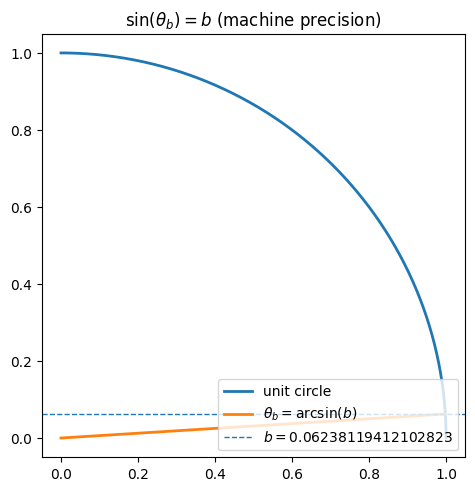

In [3]:
# 3. Geometry: on the unit circle sin(theta_b) == b to machine precision
import matplotlib.pyplot as plt
import numpy as np

t = np.linspace(0, np.pi / 2, 256)
fig, ax = plt.subplots(figsize=(5.2, 4.8), constrained_layout=True)
ax.plot(np.cos(t), np.sin(t), lw=2, label="unit circle")
ax.plot([0, np.cos(tb_local)], [0, np.sin(tb_local)], lw=2,
        label=r"$\theta_b = \arcsin(b)$")
ax.axhline(b_local, ls="--", lw=1,
           label=rf"$b = {b_local:.17f}$")
ax.set_aspect("equal")
ax.set_title(r"$\sin(\theta_b) = b$ (machine precision)")
ax.legend(loc="lower right")
plt.show()
